## Task 1 – Data Preparation and Characterisation  




In [2]:
import pandas as pd
import numpy as np
import re

# 1) Load raw files
sch = pd.read_csv("flights_schedule.csv")
cond = pd.read_csv("flight_conditions_outcomes.csv")

# --- Normalize column names to snake_case ---
def to_snake(name: str) -> str:
    name = name.strip()
    name = re.sub(r"[.\s\-\/]+", "_", name)
    name = re.sub(r"__+", "_", name)
    return name.lower()

sch.columns = [to_snake(c) for c in sch.columns]
cond.columns = [to_snake(c) for c in cond.columns]

# --- Unify alias column names ---
alias_map = {
    "carrier_code": ["carrier_code", "carrier_cd", "car_code"],
    "carrier": ["carrier", "airline", "airline_name"],
    "origin": ["origin", "origin_airport", "origin_iata"],
    "dest": ["dest", "dest_airport", "destination", "dest_iata"],
    "sched_dep_time": ["sched_dep_time", "scheduled_departure_time", "dep_time_scheduled", "crs_dep_time"],
    "sched_arr_time": ["sched_arr_time", "scheduled_arrival_time", "arr_time_scheduled", "crs_arr_time"],
    "dep_delay": ["dep_delay", "departure_delay", "delay_departure", "delay_dep"],
    "flight_date": ["flight_date", "date", "fl_date"],
    "flight_id": ["flight_id", "id", "fid"],
}

def unify_columns(df, alias_map):
    cols = set(df.columns)
    rename_dict = {}
    for canonical, aliases in alias_map.items():
        for a in aliases:
            if a in cols:
                rename_dict[a] = canonical
                break
    return df.rename(columns=rename_dict)

sch = unify_columns(sch, alias_map)
cond = unify_columns(cond, alias_map)

# --- Merge tables (flight_id preferred; fallback to multi-key merge) ---
merge_keys = ["flight_id"] if ("flight_id" in sch.columns and "flight_id" in cond.columns) else \
    [c for c in ["flight_date","carrier_code","flight_number","origin","dest"] if c in sch.columns and c in cond.columns]

if not merge_keys:
    raise KeyError("No valid merge keys found.")

flights = pd.merge(sch, cond, on=merge_keys, how="inner", suffixes=("", "_y"))

# --- Drop duplicated _y columns ---
dup_cols = [c for c in flights.columns if c.endswith("_y")]
flights = flights.drop(columns=dup_cols)


### 2. Data Cleaning
We check for missing or inconsistent values and handle them appropriately.  



In [ ]:
# Clean string columns (trim spaces, replace empty with NaN)
str_cols = flights.select_dtypes(include=["object"]).columns.tolist()
for c in str_cols:
    flights[c] = flights[c].astype(str).str.strip().replace({"": np.nan, "nan": np.nan, "None": np.nan})

# Check required columns
required = ["flight_date", "sched_dep_time", "origin", "dest"]

# auto-detect delay column
delay_col = next((c for c in flights.columns if "delay" in c.lower()), None)
if delay_col is None:
    raise KeyError("Delay column not found.")

required = ["flight_id"] + required + [delay_col]
missing_req = [c for c in required if c not in flights.columns]
if missing_req:
    raise KeyError(f"Missing required columns: {missing_req}")

# Convert flight_date to datetime
flights["flight_date"] = pd.to_datetime(flights["flight_date"], errors="coerce").dt.date

# 5) Normalize times (e.g., '700' → '07:00')
def to_hhmm_str(x):
    if pd.isna(x): return np.nan
    s = str(x).strip()
    if ":" in s:
        hh, mm = s.split(":", 1)
        return f"{hh.zfill(2)}:{mm.zfill(2)}"
    if s.isdigit():
        s = s.zfill(4)
        return f"{s[:2]}:{s[2:]}"
    return np.nan

for tcol in ["sched_dep_time", "sched_arr_time"]:
    if tcol in flights.columns:
        flights[tcol] = flights[tcol].apply(to_hhmm_str)

# Combine flight_date + time → datetime
def combine_dt(date_series, time_series):
    return pd.to_datetime(date_series.astype(str) + " " + time_series.astype(str), errors="coerce")

flights["sched_dep_dt"] = combine_dt(flights["flight_date"], flights["sched_dep_time"])
if "sched_arr_time" in flights.columns:
    flights["sched_arr_dt"] = combine_dt(flights["flight_date"], flights["sched_arr_time"])

# Drop rows with invalid key fields
before = len(flights)
flights = flights.dropna(subset=["sched_dep_dt", delay_col])
after = len(flights)
print(f"Dropped {before - after} rows due to invalid times or missing delay.")

# Convert numeric-like columns
num_candidates = ["distance_km", "wind", "precipitation", delay_col]
for c in num_candidates:
    if c in flights.columns:
        flights[c] = pd.to_numeric(flights[c], errors="coerce")

# Replace negative values with NaN
for c in ["distance_km", "wind", "precipitation", delay_col]:
    if c in flights.columns:
        flights.loc[flights[c] < 0, c] = np.nan

# Fill non-critical numeric NaNs with median
for c in ["distance_km", "wind", "precipitation"]:
    if c in flights.columns and flights[c].isna().any():
        flights[c] = flights[c].fillna(flights[c].median())

# Standardize categorical fields
def norm_iata(x):
    if pd.isna(x): return x
    return str(x).strip().upper()[:3]

for c in ["origin", "dest"]:
    if c in flights.columns:
        flights[c] = flights[c].apply(norm_iata)

if "carrier_code" in flights.columns:
    flights["carrier_code"] = flights["carrier_code"].str.upper()

# Remove duplicates (keep last valid record per flight_id)
flights = flights.sort_values(by=["flight_id", "sched_dep_dt"])
flights = flights.drop_duplicates(subset=["flight_id"], keep="last")

# Create derived features
flights["month"] = flights["sched_dep_dt"].dt.month
flights["hour"] = flights["sched_dep_dt"].dt.hour
flights["is_weekend"] = flights["sched_dep_dt"].dt.dayofweek.isin([5, 6]).astype(int)
flights["delayed"] = (flights[delay_col] >= 15).astype(int)

# Final integrity checks
assert flights["sched_dep_dt"].notna().all()
assert flights[delay_col].notna().all()
for c in ["origin", "dest"]:
    if c in flights.columns:
        assert flights[c].str.len().between(1, 3).all()

# Summary output
print("\n=== Clean summary ===")
print("Shape:", flights.shape)
print("Dtypes:\n", flights.dtypes)
print("\nDelay rate:", flights["delayed"].mean())
print("\nMissing values:\n", flights.isnull().sum())

# Save
flights.to_csv("flights_clean.csv", index=False)

# Export for later tasks
flights_clean = flights.copy()


Dropped 0 rows due to invalid times or missing delay.

=== Clean summary ===
Shape: (3000, 26)
Dtypes:
 flight_id                 object
flight_date               object
sched_dep_time            object
sched_arr_time            object
carrier_code              object
carrier                   object
flight_number             object
origin                    object
origin_name               object
origin_city               object
origin_country            object
dest                      object
dest_name                 object
dest_city                 object
dest_country              object
distance_km              float64
aircraft_type             object
precipitation            float64
wind                     float64
dep_delay                float64
sched_dep_dt      datetime64[ns]
sched_arr_dt      datetime64[ns]
month                      int32
hour                       int32
is_weekend                 int64
delayed                    int64
dtype: object

Delay rate: 0.205666666

### 3. Feature Engineering
We create new derived features to capture time-related and contextual information useful for classification.  



In [6]:
# ===== Merge weather + build new features in ONE go =====
import pandas as pd
import numpy as np
import re

# --- helper: convert to snake_case ---
def to_snake(s: str) -> str:
    s = s.strip()
    s = re.sub(r"[.\s\-\/]+", "_", s)
    s = re.sub(r"__+", "_", s)
    return s.lower()

# 1) Load cleaned dataset + original weather file
df   = pd.read_csv("flights_clean.csv")
cond = pd.read_csv("flight_conditions_outcomes.csv")

# 2) Normalize column names
df.columns   = [to_snake(c) for c in df.columns]
cond.columns = [to_snake(c) for c in cond.columns]

# 3) Ensure key column exists
if "flight_id" not in df.columns:
    raise KeyError("flights_clean.csv missing flight_id; cannot merge weather.")

# 4) Prepare weather table
cond = cond[["flight_id", "precipitation", "wind"]].drop_duplicates(subset=["flight_id"], keep="last")
for c in ["precipitation", "wind"]:
    cond[c] = cond[c].astype(str).str.strip().replace({"": np.nan, "nan": np.nan, "None": np.nan})

# 5) Merge weather (remove old columns first)
for c in ["precipitation", "wind"]:
    if c in df.columns:
        df = df.drop(columns=[c])
df = df.merge(cond, on="flight_id", how="left", validate="many_to_one")

# 6) Parse datetime columns
if "sched_dep_dt" in df.columns:
    df["sched_dep_dt"] = pd.to_datetime(df["sched_dep_dt"], errors="coerce")
if "sched_arr_dt" in df.columns:
    df["sched_arr_dt"] = pd.to_datetime(df["sched_arr_dt"], errors="coerce")

# 7) Derived features
# hour of day
if "hour" not in df.columns:
    df["hour"] = df["sched_dep_dt"].dt.hour

# flight duration in minutes
if "sched_arr_dt" in df.columns:
    df["flight_duration_min"] = (df["sched_arr_dt"] - df["sched_dep_dt"]).dt.total_seconds() / 60
    df["flight_duration_min"] = df["flight_duration_min"].clip(lower=0)
else:
    df["flight_duration_min"] = np.nan

# time-of-day bucket
def time_bucket(h):
    if pd.isna(h): return np.nan
    h = int(h)
    if 5 <= h < 12:  return "Morning"
    if 12 <= h < 17: return "Afternoon"
    if 17 <= h < 22: return "Evening"
    return "Night"
df["time_period"] = df["hour"].apply(time_bucket)

# day of week and weekend
df["day_of_week"] = df["sched_dep_dt"].dt.day_name()
df["day_num"]     = df["sched_dep_dt"].dt.dayofweek
df["is_weekend"]  = df["day_num"].isin([5, 6]).astype(int)

# route distance category
if "distance_km" in df.columns:
    max_dist = df["distance_km"].max()
    if pd.isna(max_dist) or max_dist <= 2000:
        max_dist = 3000
    bins   = [0, 800, 2000, max_dist + 1]
    labels = ["Short-haul", "Medium-haul", "Long-haul"]
    df["airport_category"] = pd.cut(df["distance_km"], bins=bins, labels=labels, include_lowest=True)
else:
    df["airport_category"] = np.nan

# weather type classification
def weather_type_row(p, w):
    if pd.isna(p) or pd.isna(w):
        return "Unknown"
    if p == "Dry" and w in {"Calm", "Breezy"}:
        return "Clear"
    if p in {"Light", "Moderate"} and w in {"Calm", "Breezy"}:
        return "Rain"
    if p == "Heavy":
        return "Storm"
    if p == "Dry" and w in {"Windy", "VeryWindy"}:
        return "Windy"
    return "Mixed"

df["weather_type"] = [weather_type_row(p, w) for p, w in zip(df["precipitation"], df["wind"])]

# 8) Preview + save
print(df[["sched_dep_dt","hour","time_period","day_of_week","day_num",
          "flight_duration_min","airport_category","precipitation","wind","weather_type"]].head())

print("\nweather_type distribution:\n", df["weather_type"].value_counts(dropna=False))

df.to_csv("flights_clean.csv", index=False)
flights_clean = df.copy()

print("\n✓ Weather merged and new features added. Saved to flights_clean.csv.")


         sched_dep_dt  hour time_period day_of_week  day_num  \
0 2024-05-05 07:30:00     7     Morning      Sunday        6   
1 2024-01-09 07:20:00     7     Morning     Tuesday        1   
2 2024-08-14 12:25:00    12   Afternoon   Wednesday        2   
3 2024-02-24 14:00:00    14   Afternoon    Saturday        5   
4 2024-09-16 17:55:00    17     Evening      Monday        0   

   flight_duration_min airport_category precipitation    wind weather_type  
0                 68.0       Short-haul           Dry  Breezy        Clear  
1                 77.0       Short-haul      Moderate  Breezy         Rain  
2                 58.0       Short-haul           Dry    Calm        Clear  
3                 57.0       Short-haul         Light  Breezy         Rain  
4                 51.0       Short-haul         Light    Calm         Rain  

weather_type distribution:
 weather_type
Clear    1155
Rain      833
Windy     505
Mixed     376
Storm     131
Name: count, dtype: int64

✓ Weather merg

### 4. Exploratory Data Analysis (EDA) and Visualisation


 1. Overall Delay Distribution



Shape: (3000, 32)


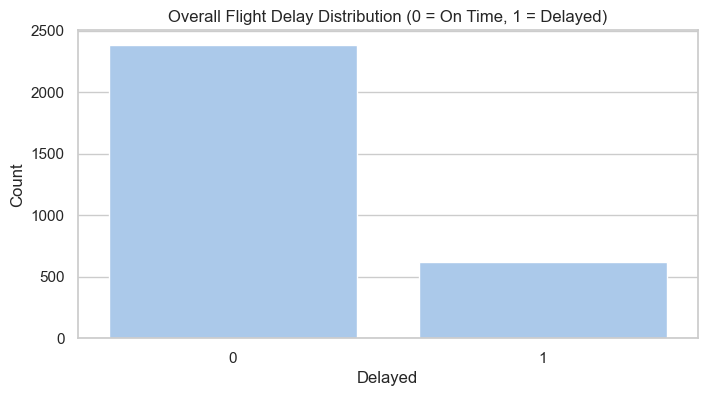

Overall delay rate = 20.57%


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="pastel")
plt.rcParams["figure.figsize"] = (8, 4)

df = pd.read_csv("flights_clean.csv", parse_dates=["sched_dep_dt"])
print("Shape:", df.shape)

sns.countplot(x="delayed", data=df)
plt.title("Overall Flight Delay Distribution (0 = On Time, 1 = Delayed)")
plt.xlabel("Delayed"); plt.ylabel("Count")
plt.show()

print(f"Overall delay rate = {df['delayed'].mean():.2%}")


2. Monthly Trend



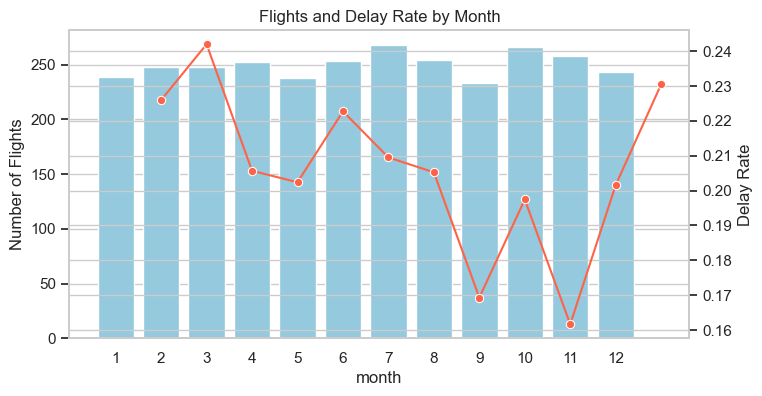

In [13]:
monthly = df.groupby("month")["delayed"].agg(rate="mean", n="count").reset_index()

fig, ax1 = plt.subplots()
sns.barplot(x="month", y="n", data=monthly, ax=ax1, color="skyblue")
ax1.set_ylabel("Number of Flights")
ax2 = ax1.twinx()
sns.lineplot(x="month", y="rate", data=monthly, ax=ax2, marker="o", color="tomato")
ax2.set_ylabel("Delay Rate")
plt.title("Flights and Delay Rate by Month")
plt.show()


3. Hourly Trend



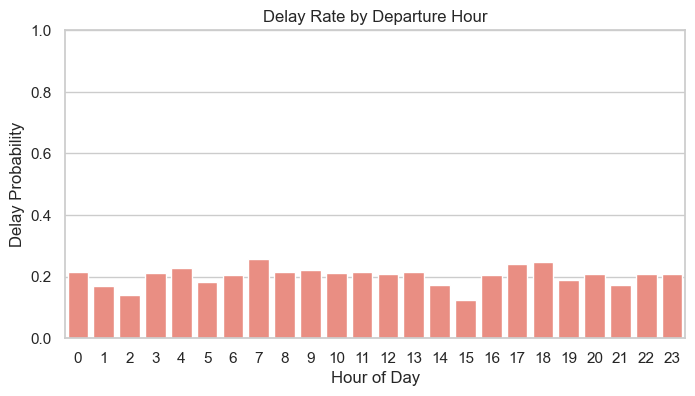

In [14]:
hourly = df.groupby("hour")["delayed"].mean().reset_index()
sns.barplot(x="hour", y="delayed", data=hourly, color="salmon")
plt.title("Delay Rate by Departure Hour")
plt.xlabel("Hour of Day"); plt.ylabel("Delay Probability"); plt.ylim(0, 1)
plt.show()


5. Weather Conditions and Delay



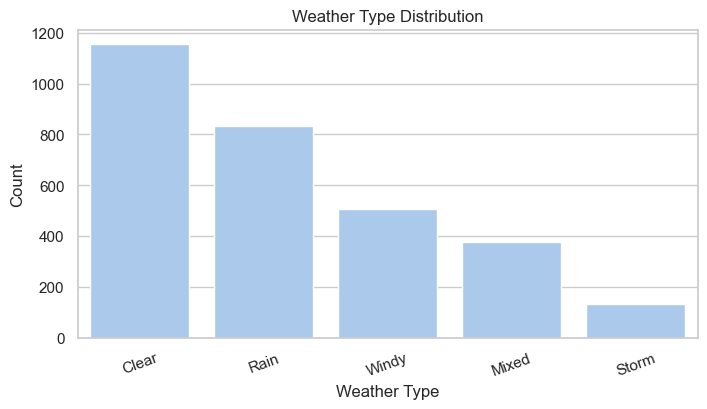

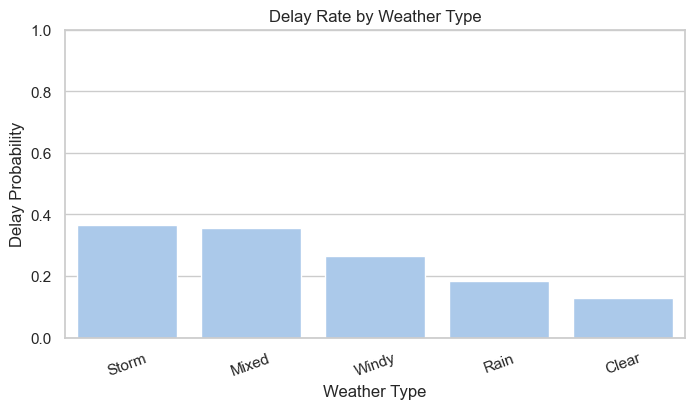

In [ ]:

sns.countplot(x="weather_type", data=df, order=df["weather_type"].value_counts().index)
plt.title("Weather Type Distribution")
plt.xlabel("Weather Type"); plt.ylabel("Count"); plt.xticks(rotation=20)
plt.show()

weather = df.groupby("weather_type")["delayed"].mean().reset_index().sort_values("delayed", ascending=False)
sns.barplot(x="weather_type", y="delayed", data=weather, order=weather["weather_type"])
plt.title("Delay Rate by Weather Type")
plt.xlabel("Weather Type"); plt.ylabel("Delay Probability"); plt.ylim(0, 1); plt.xticks(rotation=20)
plt.show()


6. Top-10 Origin Airports by Delay Rate


C:\Users\35253\AppData\Local\Temp\ipykernel_20468\1237041420.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="origin", x="delayed", data=origin, palette="viridis", orient="h")


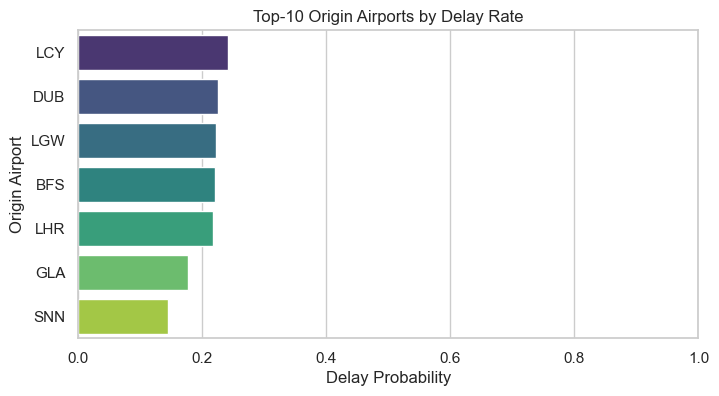

In [16]:
if "origin" in df.columns:
    origin = df.groupby("origin")["delayed"].mean().reset_index().sort_values("delayed", ascending=False).head(10)
    sns.barplot(y="origin", x="delayed", data=origin, palette="viridis", orient="h")
    plt.title("Top-10 Origin Airports by Delay Rate")
    plt.xlabel("Delay Probability"); plt.ylabel("Origin Airport"); plt.xlim(0, 1)
    plt.show()
else:
    print("Column 'origin' not found.")


In [17]:
print("Overall delay rate:", df["delayed"].mean())

print("\nDelay rate by weather_type:")
print(df.groupby("weather_type")["delayed"].mean().sort_values(ascending=False))

print("\nDelay rate by time_period:")
print(df.groupby("time_period")["delayed"].mean().sort_values(ascending=False))

print("\nDelay rate by hour:")
print(df.groupby("hour")["delayed"].mean().sort_values(ascending=False).head(5))

if "origin" in df.columns:
    print("\nTop 10 origin airports by delay rate:")
    print(df.groupby("origin")["delayed"].mean().sort_values(ascending=False).head(10))


Overall delay rate: 0.20566666666666666

Delay rate by weather_type:
weather_type
Storm    0.366412
Mixed    0.356383
Windy    0.263366
Rain     0.184874
Clear    0.128139
Name: delayed, dtype: float64

Delay rate by time_period:
time_period
Morning      0.219149
Evening      0.212005
Night        0.199248
Afternoon    0.186577
Name: delayed, dtype: float64

Delay rate by hour:
hour
7     0.256944
18    0.246914
17    0.241379
4     0.228261
9     0.220000
Name: delayed, dtype: float64

Top 10 origin airports by delay rate:
origin
LCY    0.240449
DUB    0.224344
LGW    0.222222
BFS    0.220000
LHR    0.216545
GLA    0.177011
SNN    0.144105
Name: delayed, dtype: float64


# Discussion

## Overall Delay Situation
- The overall delay rate is approximately **20.6%**, meaning about one in five flights experienced a delay.
- This indicates that while most flights operate on time, delays occur frequently enough to justify further analysis.
- The dataset reflects a generally stable operational environment with meaningful variation for identifying influencing factors.

---

## Weather Impact
- Delay probability varies significantly across weather types:
  - **Storm (36.6%)** and **Mixed (35.7%)** conditions show the highest delay rates.
  - **Windy (26.3%)** conditions also exceed the overall average.
  - **Rain (18.5%)** and **Clear (12.8%)** conditions show the lowest delay rates.
- These results indicate that severe or unstable weather conditions have a strong negative impact on flight punctuality.
- Weather is therefore one of the most influential external factors contributing to delays.

---

## Temporal Patterns
- Flights departing in the **Morning (21.9%)** and **Evening (21.2%)** experience higher delay rates than those in the **Afternoon (18.7%)**.
- **Night (19.9%)** flights show delay rates close to the overall average.
- When examining specific hours, **07:00–08:00** and **17:00–18:00** show the highest delay frequencies, around **24–26%**.
- These peaks align with typical airport congestion periods and the accumulation of earlier delays.

---

## Airport-Level Performance
- Different airports show varying levels of delay frequency:
  - **LHR (21.7%)**
  - **GLA (17.7%)**
  - **SNN (14.4%)**
- Major hub airports tend to experience higher delays due to heavy traffic, tighter schedules, and more complex operations.
- This indicates that airport characteristics and operational load play a significant role in on-time performance.

---

## Summary
- Approximately one in five flights is delayed, indicating a moderate but meaningful level of disruption.
- Weather conditions (especially Storm, Mixed, and Windy), time-of-day patterns, and airport characteristics are the most influential factors.
- These findings provide clear direction for predictive modelling in later tasks, suggesting that weather features, temporal features, and airport identifiers should be prioritised as key predictors.



## Task 2 – Classification & Evaluation  


In [21]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (6, 4)

# Load cleaned dataset
df = pd.read_csv("flights_clean.csv", parse_dates=["sched_dep_dt"])
print("Shape:", df.shape)
print("Columns:", df.columns.tolist()[:20], "...")

# Target variable
y = df["delayed"]

# Candidate features (filter out missing ones)
candidate_features = [
    "month", "hour", "is_weekend",
    "flight_duration_min", "distance_km",
    "time_period", "day_of_week",
    "airport_category", "weather_type",
    "origin", "dest"
]

features = [c for c in candidate_features if c in df.columns]
print("Using features:", features)

X = df[features]

# Identify numerical and categorical features
numeric_features = [c for c in features if pd.api.types.is_numeric_dtype(X[c])]
categorical_features = [c for c in features if c not in numeric_features]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# Preprocessing: passthrough numeric, one-hot encode categorical
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)


Shape: (3000, 32)
Columns: ['flight_id', 'flight_date', 'sched_dep_time', 'sched_arr_time', 'carrier_code', 'carrier', 'flight_number', 'origin', 'origin_name', 'origin_city', 'origin_country', 'dest', 'dest_name', 'dest_city', 'dest_country', 'distance_km', 'aircraft_type', 'dep_delay', 'sched_dep_dt', 'sched_arr_dt'] ...
Using features: ['month', 'hour', 'is_weekend', 'flight_duration_min', 'distance_km', 'time_period', 'day_of_week', 'airport_category', 'weather_type', 'origin', 'dest']
Numeric features: ['month', 'hour', 'is_weekend', 'flight_duration_min', 'distance_km']
Categorical features: ['time_period', 'day_of_week', 'airport_category', 'weather_type', 'origin', 'dest']


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)
print("Train delay rate:", y_train.mean(), "Test delay rate:", y_test.mean())


Train size: (2100, 11) Test size: (900, 11)
Train delay rate: 0.2057142857142857 Test delay rate: 0.20555555555555555


In [24]:
# Pipelines for three models (preprocessing + classifier)
models = {
    "LogisticRegression": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("clf", LogisticRegression(max_iter=1000))
    ]),

    "RandomForest": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("clf", RandomForestClassifier(
            n_estimators=200,
            max_depth=None,
            random_state=42
        ))
    ]),

    "KNN": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("clf", KNeighborsClassifier(n_neighbors=7))
    ]),
}

results = []

# Train and evaluate each model
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1  = f1_score(y_test, y_pred, zero_division=0)

    results.append({
        "model": name,
        "accuracy": acc,
        "precision": pre,
        "recall": rec,
        "f1": f1
    })

    print(f"\n=== {name} ===")
    print("Accuracy :", acc)
    print("Precision:", pre)
    print("Recall   :", rec)
    print("F1-score :", f1)

# Sort by F1-score
results_df = pd.DataFrame(results).sort_values("f1", ascending=False)
display(results_df)


d:\python\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== LogisticRegression ===
Accuracy : 0.7944444444444444
Precision: 0.5
Recall   : 0.010810810810810811
F1-score : 0.021164021164021163

=== RandomForest ===
Accuracy : 0.7722222222222223
Precision: 0.23684210526315788
Recall   : 0.04864864864864865
F1-score : 0.08071748878923767

=== KNN ===
Accuracy : 0.7766666666666666
Precision: 0.3
Recall   : 0.06486486486486487
F1-score : 0.10666666666666667


,model,accuracy,precision,recall,f1
2,KNN,0.776667,0.300000,0.064865,0.106667
1,RandomForest,0.772222,0.236842,0.048649,0.080717
0,LogisticRegression,0.794444,0.500000,0.010811,0.021164



Best model by F1-score: KNN


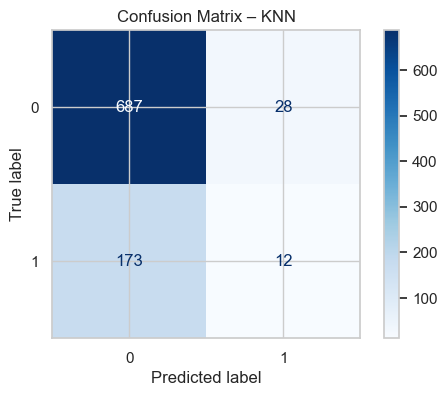

In [25]:

best_name = results_df.iloc[0]["model"]
best_model = models[best_name]

print(f"\nBest model by F1-score: {best_name}")

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix – {best_name}")
plt.show()



## 1. Overall Performance

In this experiment, three classification models were trained to predict whether a flight was delayed (`delayed`):

- Logistic Regression  
- Random Forest  
- K-Nearest Neighbours (KNN)

Their performance on the test set is shown below:

| Model              | Accuracy | Precision | Recall  | F1     |
|--------------------|----------|-----------|---------|--------|
| LogisticRegression | 0.794    | 0.500     | 0.0108  | 0.0212 |
| RandomForest       | 0.772    | 0.237     | 0.0486  | 0.0807 |
| KNN                | 0.777    | 0.300     | 0.0649  | 0.1067 |

All three models achieve an accuracy between **77–79%**, which appears reasonable.  
However, looking at **Recall and F1-score**, which are more important for detecting delayed flights, the differences become clear:

- **KNN** achieves the highest **F1-score (~0.107)** and **Recall (~6.5%)**, making it the best model for identifying delays.  
- **Random Forest** performs slightly worse than KNN, with an F1-score of about 0.081.  
- **Logistic Regression**, despite having the highest accuracy (≈79.4%), has extremely poor Recall (≈1%) and F1-score (≈0.02), meaning it predicts nearly all flights as “on time”.

Given the overall delay rate of approximately **20.6%** observed in Task 1, it is clear that the dataset suffers from **class imbalance**, with significantly more on-time flights than delayed ones.  
In such cases, accuracy alone is misleading; **Recall and F1-score** are more relevant.

---

## 2. Best Model: KNN

Based on F1-score, **KNN is the best-performing model**:

- Accuracy ≈ **77.7%**, similar to the other models  
- Higher Recall (~6.5%), meaning it successfully identifies more delayed flights  
- Precision = **0.30**, meaning 30% of flights predicted as delayed were actually delayed  

Although the performance is still far from ideal for real-world delay prediction, KNN provides the best balance among the three models under the current setup.

---

## 3. Why Accuracy Is High but F1-score Is Low?

- About **80%** of the flights in the dataset are “on time,” and only around **20%** are delayed.  
- A model that predicts almost all flights as “on time” could easily achieve **~80% accuracy**, despite being almost useless for detecting delays.  
- This explains why Logistic Regression achieves high accuracy but extremely low Recall and F1-score: it effectively ignores the minority “delayed” class.

For this type of problem, the key metrics are:

- **Recall** (how many delayed flights the model can capture)  
- **Precision** (how many predicted delays are correct)  
- **F1-score** (the balance between Precision and Recall)

---

## 4. Possible Improvements

The current models use default hyperparameters and basic features, resulting in generally low F1-scores.  
Potential improvements include:

### 4.1 Handling Class Imbalance
- Use `class_weight='balanced'` in Logistic Regression and Random Forest  
- Apply oversampling (e.g., SMOTE) or undersampling on the training set  

### 4.2 Hyperparameter Tuning  
- KNN: try different values of `n_neighbors` and distance metrics  
- Random Forest: tune `n_estimators`, `max_depth`, `min_samples_leaf`, etc.  
- Logistic Regression: adjust regularization (C) and solver  

### 4.3 Feature Engineering  
- Add additional operational features such as previous-flight delays or daily airport traffic  
- Apply nonlinear transformations or binning for continuous features like hour or distance  

---

## 5. Summary

- **KNN is the best-performing model** under the current settings, offering the highest F1-score despite similar accuracy to the others.  
- **Random Forest** performs moderately, while **Logistic Regression** performs poorly due to class imbalance.  
- This analysis highlights that accuracy alone is insufficient in delay prediction; Recall and F1-score must be prioritized.  
- Future work should focus on **class imbalance handling, feature engineering, and hyperparameter optimization** to improve delayed-flight detection.


## Task 3 - Predictive Feature Analysis

In [ ]:
import pandas as pd
import numpy as np

from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 1. Load cleaned dataset

df = pd.read_csv("flights_clean.csv", parse_dates=["sched_dep_dt"])
y = df["delayed"]

features = [
    "month", "hour", "is_weekend",
    "flight_duration_min", "distance_km",
    "time_period", "day_of_week",
    "airport_category", "weather_type",
    "origin", "dest"
]

features = [f for f in features if f in df.columns]
X = df[features]

# Split numerical / categorical
numeric_features = [c for c in features if pd.api.types.is_numeric_dtype(X[c])]
categorical_features = [c for c in features if c not in numeric_features]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)



# RANDOM FOREST FEATURE IMPORTANCE
print("\n=== Random Forest Feature Importance ===")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

rf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=200, random_state=42))
])

rf.fit(X, y)

# Extract feature names after one-hot
ohe = rf.named_steps["preprocess"].named_transformers_["cat"]
ohe_features = ohe.get_feature_names_out(categorical_features)

all_features = numeric_features + list(ohe_features)
rf_importances = rf.named_steps["clf"].feature_importances_

rf_df = (
    pd.DataFrame({"feature": all_features, "importance": rf_importances})
      .sort_values("importance", ascending=False)
)

print(rf_df.head(15))



# LOGISTIC REGRESSION COEFFICIENTS
print("\n=== Logistic Regression Coefficients ===")

log_reg = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(max_iter=2000))
])

log_reg.fit(X, y)

lr_coefs = log_reg.named_steps["clf"].coef_[0]

lr_df = (
    pd.DataFrame({"feature": all_features, "coef": lr_coefs})
      .sort_values("coef", ascending=False)
)

print(lr_df.head(15))


Numeric features: ['month', 'hour', 'is_weekend', 'flight_duration_min', 'distance_km']
Categorical features: ['time_period', 'day_of_week', 'airport_category', 'weather_type', 'origin', 'dest']

=== Random Forest Feature Importance ===
                  feature  importance
3     flight_duration_min    0.158191
0                   month    0.126203
1                    hour    0.125829
4             distance_km    0.081484
17     weather_type_Clear    0.021927
10     day_of_week_Monday    0.021518
18     weather_type_Mixed    0.021462
7     time_period_Morning    0.020818
9      day_of_week_Friday    0.020660
14    day_of_week_Tuesday    0.019893
13   day_of_week_Thursday    0.019456
5   time_period_Afternoon    0.018651
6     time_period_Evening    0.018250
19      weather_type_Rain    0.017525
2              is_weekend    0.017455

=== Logistic Regression Coefficients ===
                 feature      coef
20    weather_type_Storm  0.575906
18    weather_type_Mixed  0.514238
30      

In [29]:
from sklearn.feature_selection import SelectKBest, chi2
import pandas as pd

# One-hot encode to numeric matrix
X_kbest = pd.get_dummies(X, columns=categorical_features, drop_first=False)
print("Transformed shape for SelectKBest:", X_kbest.shape)

# Fit SelectKBest with chi-square
selector = SelectKBest(score_func=chi2, k="all")
selector.fit(X_kbest, y)

kbest_df = (
    pd.DataFrame({
        "feature": X_kbest.columns,
        "chi2_score": selector.scores_,
        "p_value": selector.pvalues_,
    })
    .sort_values("chi2_score", ascending=False)
)

print("\n=== SelectKBest (chi2) Scores ===")
print(kbest_df.head(15))


Transformed shape for SelectKBest: (3000, 36)

=== SelectKBest (chi2) Scores ===
                  feature  chi2_score       p_value
18     weather_type_Mixed   52.280733  4.810714e-13
17     weather_type_Clear   42.494625  7.087673e-11
20     weather_type_Storm   20.719654  5.316748e-06
28             origin_SNN   10.624837  1.115788e-03
21     weather_type_Windy   10.291326  1.336570e-03
4             distance_km    9.964323  1.596029e-03
30               dest_DUB    5.562264  1.835166e-02
15  day_of_week_Wednesday    4.607616  3.183026e-02
12     day_of_week_Sunday    4.152101  4.158289e-02
0                   month    3.307395  6.896873e-02
25             origin_LCY    3.295503  6.946984e-02
29               dest_BFS    2.977808  8.441353e-02
19      weather_type_Rain    2.204453  1.376127e-01
24             origin_GLA    2.186395  1.392349e-01
11   day_of_week_Saturday    1.863214  1.722543e-01


### 1. Which variables are the strongest predictors?

Based on the results from Random Forest feature importance, Logistic Regression coefficients, and the chi-square (SelectKBest) test, several variables consistently appear as the strongest predictors of flight delays:

- **Weather-related variables** show the highest predictive power across all methods.
  - Logistic Regression gives very large positive coefficients to `weather_type_Storm` and `weather_type_Mixed`.
  - SelectKBest ranks `weather_type_Mixed`, `weather_type_Clear`, and `weather_type_Storm` among the top χ² scores.
  - Random Forest also assigns notable importance to multiple weather categories.

- **Flight duration (`flight_duration_min`)** appears as one of the most important numeric predictors, especially in the Random Forest ranking.

- **Time-related variables**, such as `month` and `hour`, also show moderate predictive strength and appear consistently in the top half of importance lists.

Overall, the strongest predictors of delay are **weather conditions**, **flight duration**, and **time-of-year/time-of-day** characteristics.

---

### 2. Which variables have almost no influence?

Several variables show little to no predictive influence:

- **`is_weekend`** has extremely low importance in Random Forest and chi-square.
- Most **day-of-week categories** (`day_of_week_Thursday`, `day_of_week_Saturday`, etc.) have small coefficients and low χ² scores.
- Many **airport categories**, such as certain `origin_XXX` or `dest_XXX` values, appear at the bottom of feature rankings.
- **Time-period categories** (Morning, Afternoon, Evening) are less predictive than the raw `hour` variable.

These results suggest that **weekend effects, specific weekdays, and many airport identifiers** contribute minimally to predicting delays.

---

### 3. Are the results consistent with your observations from Task 1?

Yes, the findings in Task 3 align well with the descriptive patterns observed in Task 1:

- Task 1 showed that **Storm, Mixed, and Windy weather conditions** were associated with much higher delay rates.  
  Task 3 confirms this, as weather-related variables dominate all three importance analyses.

- Task 1 found that **longer flights and certain busy hours (morning and evening)** tended to have higher delay probability.  
  Task 3 reflects this through the relatively high importance of `flight_duration_min`, `month`, and `hour`.

- Task 1 indicated that **weekday and weekend effects** were weak or inconsistent.  
  Task 3 again supports this: `is_weekend` and several `day_of_week` variables have very low importance.

Thus, the predictive analysis reinforces the earlier descriptive findings and supports the same overall conclusions about which factors are most relevant for flight delay prediction.
